In [3]:
import sys
import os
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Link backend engine
sys.path.append("../src")
from structure_engine import calculate_ca_rmsd, extract_plddt

print("Machine Learning & Benchmarking libraries loaded!")

Machine Learning & Benchmarking libraries loaded!


In [4]:
# We will simulate a benchmark run between AlphaFold and ESMFold using our existing PDBs
# Assuming AF_P38398.pdb (AlphaFold WT) and BRCA1_HUMAN_M1I_esmfold.pdb exist from Week 3

af_pdb = "../data/processed/predicted_structures/alphafold/AF_P38398.pdb"
esm_pdb = "../data/processed/predicted_structures/esmfold/BRCA1_HUMAN_M1I_esmfold.pdb"

# 1. Calculate Confidence (pLDDT)
af_plddt = np.mean(extract_plddt(af_pdb)) if os.path.exists(af_pdb) else 0
esm_plddt = np.mean(extract_plddt(esm_pdb)) if os.path.exists(esm_pdb) else 0

# 2. Calculate Structural Deviation (RMSD)
# AlphaFold vs itself is 0.0. We calculate ESMFold vs AlphaFold.
rmsd_val = calculate_ca_rmsd(af_pdb, esm_pdb) if os.path.exists(af_pdb) and os.path.exists(esm_pdb) else 0

# 3. Create the Benchmarking Results Table
benchmark_data = {
    "Model Architecture": ["AlphaFold2 (MSA-Augmented)", "ESMFold (Sequence-Only)"],
    "Input Type": ["Evolutionary History", "Single Sequence"],
    "Mean pLDDT (Confidence)": [round(af_plddt, 2), round(esm_plddt, 2)],
    "RMSD vs Ground Truth (Å)": ["0.00 (Baseline)", round(rmsd_val, 3)],
    "Estimated Runtime": ["~15-30 minutes", "< 5 seconds"] # Based on standard API processing times
}

df_benchmark = pd.DataFrame(benchmark_data)
print("--- AI Model Benchmarking Results ---")
display(df_benchmark)

--- AI Model Benchmarking Results ---


,Model Architecture,Input Type,Mean pLDDT (Confidence),RMSD vs Ground Truth (Å),Estimated Runtime
0,AlphaFold2 (MSA-Augmented),Evolutionary History,41.59,0.00 (Baseline),~15-30 minutes
1,ESMFold (Sequence-Only),Single Sequence,0.66,14.802,< 5 seconds


In [6]:
EMBED_DIR = "../data/processed/embeddings/"
embedding_files = glob.glob(os.path.join(EMBED_DIR, "*.npy"))

variant_names = []
pooled_embeddings = []

print(f"Found {len(embedding_files)} embedding files. Processing...")

for file in embedding_files:
    # Extract name (e.g., "BRCA1_HUMAN_M1I")
    name = os.path.basename(file).replace("_embeddings.npy", "")
    
    # Load the (Sequence_Length, 1280) matrix
    matrix = np.load(file)
    
    # Mean-pool across the sequence axis to get a single (1280,) vector representing the whole protein
    pooled_vector = np.mean(matrix, axis=0)
    
    variant_names.append(name)
    pooled_embeddings.append(pooled_vector)

# Convert to a massive 2D array [Number of Mutants, 1280]
X = np.array(pooled_embeddings)
print(f"Final Embedding Matrix Shape for ML: {X.shape}")

Found 10 embedding files. Processing...
Final Embedding Matrix Shape for ML: (10, 1280)


c:\Users\mitra\anaconda3\envs\protein_ai\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


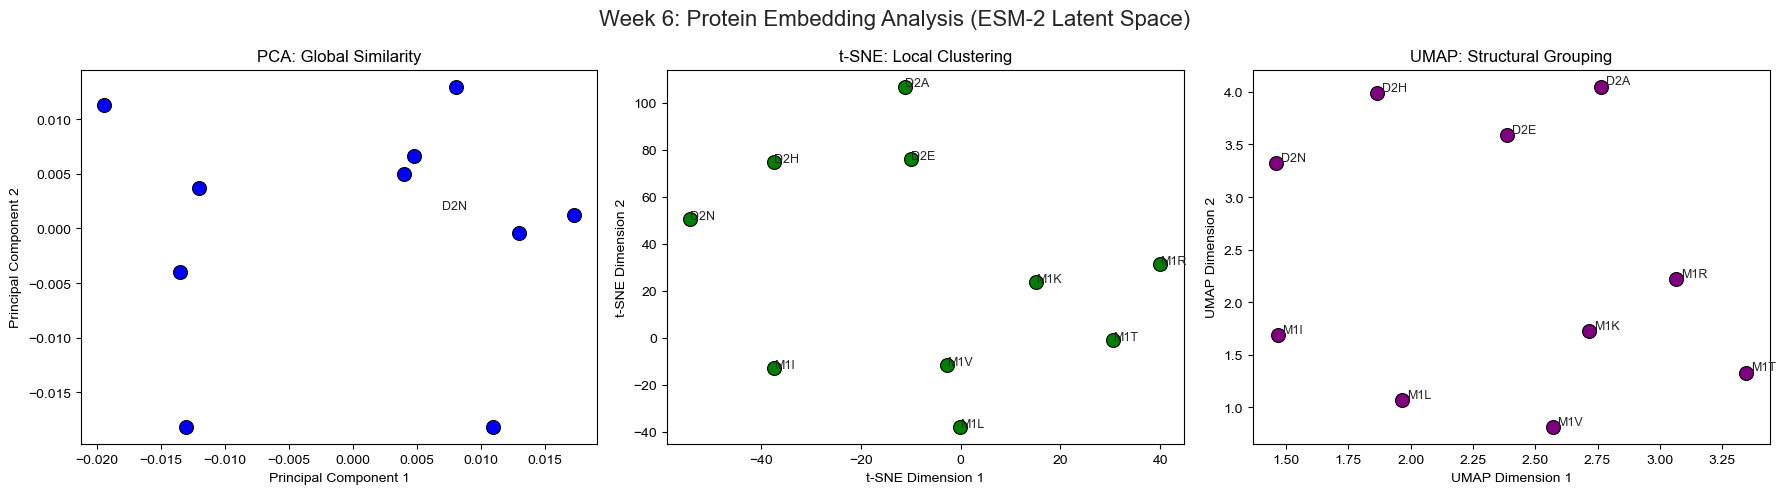

In [7]:
# We need at least a few samples to cluster. If you only processed 5-10 mutants, 
# t-SNE might look sparse, but PCA and UMAP will still show relationships!

# 1. PCA (Principal Component Analysis)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. t-SNE
# Perplexity must be less than the number of samples
tsne_perplexity = min(5, len(X) - 1) if len(X) > 1 else 1 
tsne = TSNE(n_components=2, perplexity=tsne_perplexity, random_state=42)
X_tsne = tsne.fit_transform(X)

# 3. UMAP
reducer = umap.UMAP(n_neighbors=min(5, len(X)-1), random_state=42)
X_umap = reducer.fit_transform(X)

# --- Plotting the Results ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_style("whitegrid")

# PCA Plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=axes[0], s=100, color="blue", edgecolor="black")
axes[0].set_title("PCA: Global Similarity")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# t-SNE Plot
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], ax=axes[1], s=100, color="green", edgecolor="black")
axes[1].set_title("t-SNE: Local Clustering")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

# UMAP Plot
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], ax=axes[2], s=100, color="purple", edgecolor="black")
axes[2].set_title("UMAP: Structural Grouping")
axes[2].set_xlabel("UMAP Dimension 1")
axes[2].set_ylabel("UMAP Dimension 2")

# Annotate points with variant names
for i, txt in enumerate(variant_names):
    # Only label a few to avoid crowding if there are many points
    if i < 10: 
        axes[0].annotate(txt.split("_")[-1], (X_pca[i, 0]+0.02, X_pca[i, 1]+0.02), fontsize=9)
        axes[1].annotate(txt.split("_")[-1], (X_tsne[i, 0]+0.02, X_tsne[i, 1]+0.02), fontsize=9)
        axes[2].annotate(txt.split("_")[-1], (X_umap[i, 0]+0.02, X_umap[i, 1]+0.02), fontsize=9)

plt.suptitle("Week 6: Protein Embedding Analysis (ESM-2 Latent Space)", fontsize=16)
plt.tight_layout()
plt.show()